Processing: SAMP-1_P2_Wetted_6FBz_N2_1000_10.txt
Processing: SAMP-2_F005AP_6FBz@P2_N2_1000_10.txt
Processing: SAMP-3_F005AP_6FBz@P2_N2_250_10_iso30Min_1000_10.txt
Processing: SAMP-4_F006WA_phDADQ@P2_N2_1000_10.txt
Processing: SAMP-5_F006WA_phDADQ@P2_AIR_1000_10.txt
Processing: SAMP-6_P2_N2_1000_10.txt
Processing: SAMP-7_P2_AIR_1000_10.txt


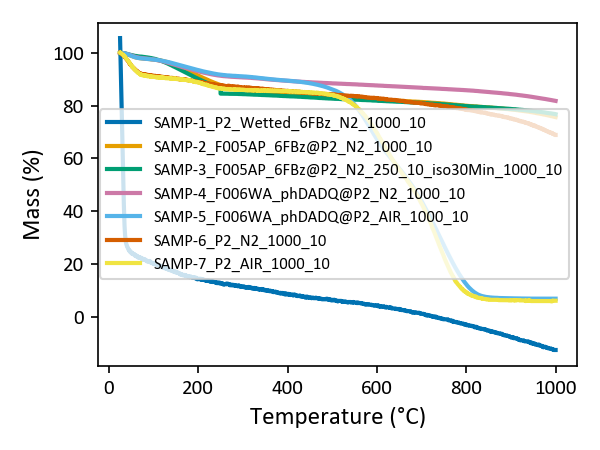

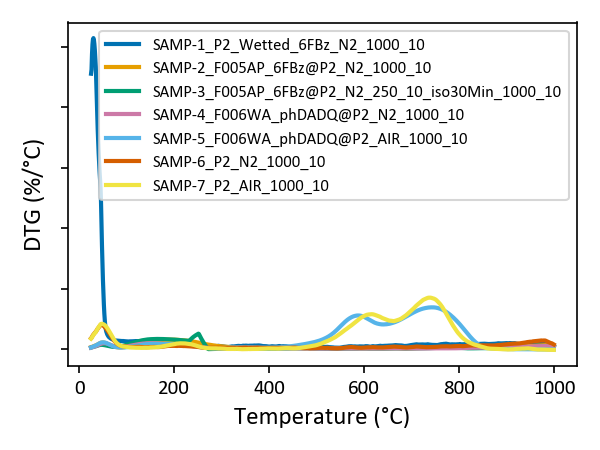

✅ All files processed and figures saved successfully!


In [4]:
# =====================================================================
# TGA & DTG Automated Folder Processing (TUB format)
# =====================================================================
%matplotlib widget
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. DIRECTORY CONFIGURATION
# =========================
# The folder containing all your new .txt files
target_dir = Path(r"H:\FUBerlin\Measurements\TGA_TUB\20260901_TGA_P2_F005_6FBz_F006_phDADQ")

# Folder to save the final figures
save_dir = Path(r"H:\FUBerlin\Writing and Summaries\TEST")
save_dir.mkdir(parents=True, exist_ok=True)


# =========================
# 2. FILE PARSING & PROCESSING
# =========================
def parse_and_process_tub_tga(file_path):
    """Reads the custom TUB .txt files, processes TGA, and computes DTG."""
    
    # --- A. READ TGA TXT ---
    with open(file_path, "r", encoding="latin1") as f:
        lines = f.readlines()

    # Find data start
    start = 0
    for i, line in enumerate(lines):
        if "Index" in line:
            start = i + 2
            break

    data = []
    for line in lines[start:]:
        parts = line.split()
        if len(parts) >= 3:
            try:
                temperature = float(parts[1].replace(",", "."))
                mass = float(parts[2].replace(",", "."))
                data.append([temperature, mass])
            except ValueError:
                pass

    df = pd.DataFrame(data, columns=["Temperature", "Mass"])
    label = file_path.stem

    # --- B. PROCESS MASS (TGA) ---
    # keep heating part only
    max_idx = df["Temperature"].idxmax()
    df = df.loc[:max_idx].copy()

    # normalize initial mass
    m0 = df["Mass"].head(10).mean()
    df["Mass (%)"] = df["Mass"] / m0 * 100
    df["Label"] = label

    # --- C. DTG CALCULATION ---
    # sort and remove duplicates for interpolation
    df_dtg = df.sort_values("Temperature").drop_duplicates("Temperature")

    # uniform temperature grid
    step = 1.0
    temp_uniform = np.arange(
        df_dtg["Temperature"].min(),
        df_dtg["Temperature"].max(),
        step
    )

    mass_uniform = np.interp(
        temp_uniform,
        df_dtg["Temperature"],
        df_dtg["Mass (%)"]
    )

    # smoothing
    window = 20
    mass_smooth = (
        pd.Series(mass_uniform)
        .rolling(window, center=True, min_periods=1)
        .mean()
        .values
    )

    # derivative
    dtg = np.gradient(mass_smooth, temp_uniform)

    # TGA convention: mass loss positive
    dtg = -dtg

    # second smoothing
    dtg = (
        pd.Series(dtg)
        .rolling(window, center=True, min_periods=1)
        .mean()
        .values
    )

    # Output DataFrames
    tga_out = df[["Temperature", "Mass (%)", "Label"]].copy()
    dtg_out = pd.DataFrame({
        "Temperature": temp_uniform,
        "DTG (%/°C)": dtg,
        "Label": label
    })

    return tga_out, dtg_out


# =========================
# 3. STYLING CONFIGURATION
# =========================
poster_style = {
    "figsize": (4, 3),
    "dpi": 150,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "font_family": "Calibri",
    "line_width": 2,
    "linestyles": ["-", "-", "-", "-", "-", "-"],
    "colors": [
        "#0072B2", "#E69F00", "#009E73", 
        "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"
    ],
    "grid": False,
    "title_weight": "normal",
    "label_weight": "normal",
    "legend_frame": False,
    "tick_size": 10,
}

def apply_plot_style(style):
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"],
        "axes.titlesize": style["title_size"],
        "axes.labelsize": style["label_size"],
        "legend.fontsize": style["legend_size"],
        "xtick.labelsize": style["tick_size"],
        "ytick.labelsize": style["tick_size"],
    })


# =========================
# 4. PLOTTING FUNCTIONS
# =========================
def plot_tga(data, style=poster_style):
    apply_plot_style(style)
    fig, ax = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])

    colors = style["colors"]
    linestyles = style["linestyles"]

    for i, df in enumerate(data):
        label = df["Label"].iloc[0]
        ax.plot(
            df["Temperature"], df["Mass (%)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[i % len(colors)] if colors else None,
            linestyle=linestyles[i % len(linestyles)] if linestyles else "-"
        )

    ax.set_xlabel("Temperature (°C)", fontsize=style["label_size"])
    ax.set_ylabel("Mass (%)", fontsize=style["label_size"])
    ax.set_xlim(None, None)
    ax.legend(fontsize=style["legend_size"], frameon=style["legend_frame"])
    
    if style["grid"]: ax.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

def plot_dtg(data, style=poster_style):
    apply_plot_style(style)
    fig, ax = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])

    colors = style["colors"]
    linestyles = style["linestyles"]

    for i, df in enumerate(data):
        label = df["Label"].iloc[0]
        ax.plot(
            df["Temperature"], df["DTG (%/°C)"],
            label=label,
            linewidth=style["line_width"],
            color=colors[i % len(colors)] if colors else None,
            linestyle=linestyles[i % len(linestyles)] if linestyles else "-"
        )

    ax.set_xlabel("Temperature (°C)", fontsize=style["label_size"])
    ax.set_ylabel("DTG (%/°C)", fontsize=style["label_size"])
    ax.set_xlim(None, None)
    ax.legend(fontsize=style["legend_size"], frameon=style["legend_frame"])
    ax.set_yticklabels([]) # Hide Y ticks like your previous style
    
    if style["grid"]: ax.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig


# =========================
# 5. AUTOMATED LOADING & EXECUTION
# =========================
TGA_DFs = []
DTG_DFs = []

# Scan the folder for all .txt files
file_list = sorted(list(target_dir.glob("*.txt")))

if not file_list:
    print(f"⚠️ Warning: No .txt files found in {target_dir}")
else:
    for file_path in file_list:
        print(f"Processing: {file_path.name}")
        try:
            # Parse the text file and calculate both arrays in one go
            tga_df, dtg_df = parse_and_process_tub_tga(file_path)
            
            TGA_DFs.append(tga_df)
            DTG_DFs.append(dtg_df)
            
        except Exception as e:
            print(f"❌ Error processing {file_path.name}: {e}")

# If we successfully parsed files, plot and save them
if TGA_DFs:
    # 1. Plot and save TGA
    fig_tga = plot_tga(TGA_DFs)
    #fig_tga.savefig(save_dir / "TGA_TUB_Format.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 2. Plot and save DTG
    fig_dtg = plot_dtg(DTG_DFs)
    #fig_dtg.savefig(save_dir / "DTG_TUB_Format.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("✅ All files processed and figures saved successfully!")

--- Generating plots for: 6FBz@P2 vs P2 (N2) - Wetting and Preheating ---


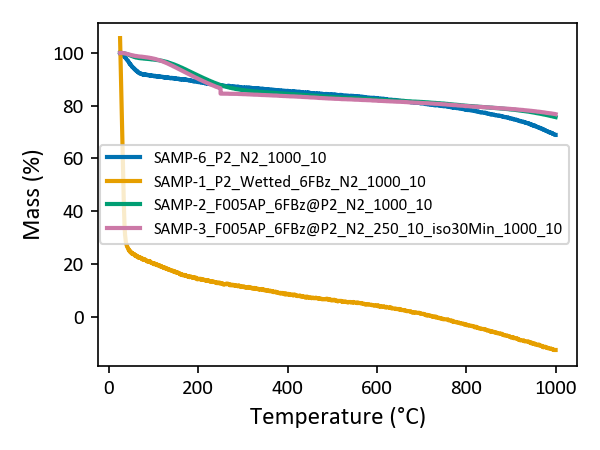

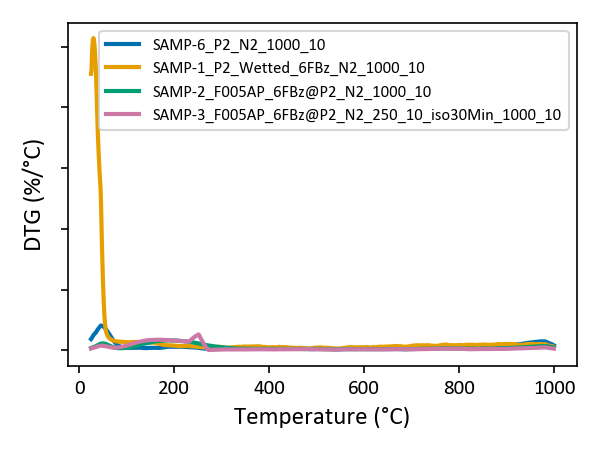

Saved 6FBz@P2 vs P2 (N2) - Wetting and Preheating figures to H:\FUBerlin\Writing and Summaries\TEST

--- Generating plots for: phDADQ@P2 vs P2 (N2) ---


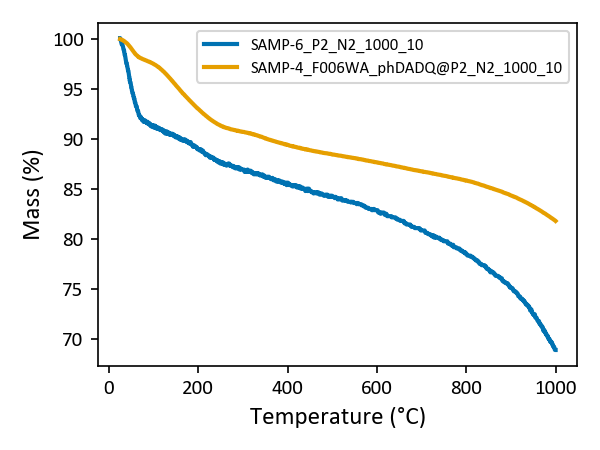

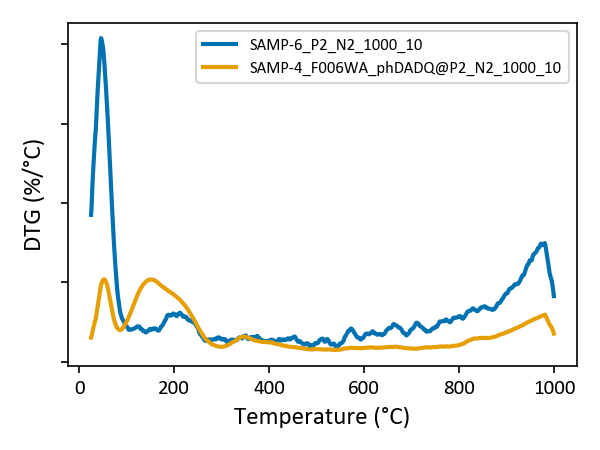

Saved phDADQ@P2 vs P2 (N2) figures to H:\FUBerlin\Writing and Summaries\TEST

--- Generating plots for: phDADQ@P2 vs P2 (Air) ---


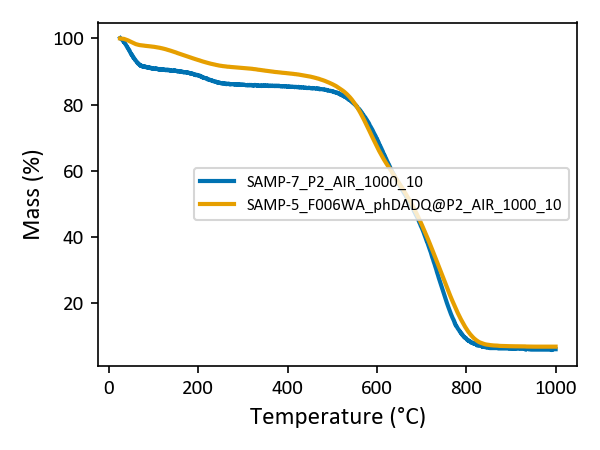

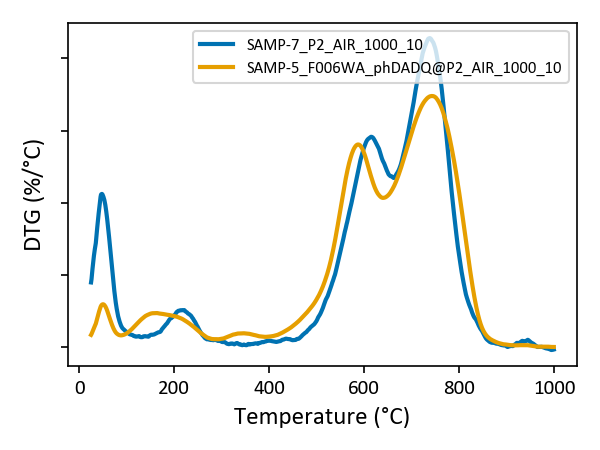

Saved phDADQ@P2 vs P2 (Air) figures to H:\FUBerlin\Writing and Summaries\TEST



In [6]:
# =====================================================================
# PLOT SPECIFIC COMPARISON GROUPS
# =====================================================================

# 1. Define the groups based on your filenames
comparisons = {
    "6FBz@P2 vs P2 (N2) - Wetting and Preheating": [
        "SAMP-6_P2_N2_1000_10",                               # Reference
        "SAMP-1_P2_Wetted_6FBz_N2_1000_10",                   # Wetted
        "SAMP-2_F005AP_6FBz@P2_N2_1000_10",                   # F005AP Standard
        "SAMP-3_F005AP_6FBz@P2_N2_250_10_iso30Min_1000_10"    # F005AP Isothermal
    ],
    
    "phDADQ@P2 vs P2 (N2)": [
        "SAMP-6_P2_N2_1000_10",                               # Reference N2
        "SAMP-4_F006WA_phDADQ@P2_N2_1000_10"                  # Sample N2
    ],
    
    "phDADQ@P2 vs P2 (Air)": [
        "SAMP-7_P2_AIR_1000_10",                              # Reference Air
        "SAMP-5_F006WA_phDADQ@P2_AIR_1000_10"                 # Sample Air
    ]
}

# 2. Iterate through each group, filter the data, and plot
for group_name, file_labels in comparisons.items():
    print(f"--- Generating plots for: {group_name} ---")
    
    # Filter the dataframes that match the labels in the current group
    # We maintain the order specified in the lists above so the reference is plotted first
    filtered_tga = []
    filtered_dtg = []
    
    for label in file_labels:
        # Find matching TGA
        match_tga = next((df for df in TGA_DFs if df["Label"].iloc[0] == label), None)
        if match_tga is not None:
            filtered_tga.append(match_tga)
            
        # Find matching DTG
        match_dtg = next((df for df in DTG_DFs if df["Label"].iloc[0] == label), None)
        if match_dtg is not None:
            filtered_dtg.append(match_dtg)
            
    if not filtered_tga:
        print(f"⚠️ No matching data found for {group_name}. Skipping.\n")
        continue

    # 3. Plot and save TGA for the group
    fig_tga = plot_tga(filtered_tga)
    # Optional: Add a title to the plot if you want
    # fig_tga.axes[0].set_title(f"TGA: {group_name.replace('_', ' ')}") 
    
    save_path_tga = save_dir / f"TGA_{group_name}.png"
    #fig_tga.savefig(save_path_tga, dpi=300, bbox_inches="tight")
    plt.show()

    # 4. Plot and save DTG for the group
    fig_dtg = plot_dtg(filtered_dtg)
    # Optional: Add a title
    # fig_dtg.axes[0].set_title(f"DTG: {group_name.replace('_', ' ')}")
    
    save_path_dtg = save_dir / f"DTG_{group_name}.png"
    #fig_dtg.savefig(save_path_dtg, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Saved {group_name} figures to {save_dir}\n")